**Sales Anaylsis with XGBoost**

Using Rossman Stores sales https://www.kaggle.com/datasets/shahpranshu27/rossman-store-sales/data

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor, callback
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder

enc = TargetEncoder(cols=["store_id", "item_id"])
X_train = enc.fit_transform(train_df[["store_id", "item_id"]], train_df["sales"])
X_test  = enc.transform(df[["store_id", "item_id"]])
df = pd.read_csv("retail_sales.csv")
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


This code builds a feature-rich dataset for a sales forecasting model by first creating target-encoded features for store_id and item_id, where each category’s average sales is smoothed toward the global mean using an alpha of 10 to reduce overfitting. It then engineers time-series and behavioral features like lagged demand proxy (sales / price), rolling means (7 and 28 periods), and exponentially weighted moving averages to capture short- and long-term trends. Finally, it adds pricing signals (log_price, price_x_promo), cleans missing values, and converts categorical columns into category dtype for more efficient modeling.

In [21]:
df = df.sort_values("date")
train_df = df[df["date"] < "2023-01-01"]
group = ["store_id", "item_id"]

df["demand_proxy"] = df["sales"] / df["price"]
g = df.groupby(group)["demand_proxy"]

df["lag_7"] = g.shift(7)

df["rolling_mean_7"] = g.transform(lambda x: x.shift(1).rolling(7).mean())
df["rolling_mean_28"] = g.transform(lambda x: x.shift(1).rolling(28).mean())

df["ewm_sales_7"] = g.transform(lambda x: x.shift(1).ewm(span=7).mean())
df["ewm_sales_28"] = g.transform(lambda x: x.shift(1).ewm(span=28).mean())

df["log_price"] = np.log1p(df["price"])
df["price_x_promo"] = df["price"] * df["promo"]

df = df.dropna()

df[["store_id", "item_id"]] = df[["store_id", "item_id"]].astype("category")

/tmp/ipykernel_28103/651935903.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(group)["demand_proxy"]
/tmp/ipykernel_28103/651935903.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["store_id", "item_id"]] = df[["store_id", "item_id"]].astype("category")


This feature list defines the input variables used for a predictive model, combining categorical identifiers, price and promotional signals, and time-series aggregates like rolling means, lagged values, and exponentially weighted trends. Together, these features capture both short-term demand dynamics and longer-term seasonal or behavioral patterns to improve forecasting accuracy.

In [26]:
feature_cols = [

    "rolling_mean_7",
    "rolling_mean_28",

    "log_price",
    "promo",
    "weekday",
    "month",

    "lag_7",
    #"lag_14",
    #"lag_28",
    #"lag_60",

    "ewm_sales_28",
    "price_x_promo",
]

This code splits the dataset into training, validation, and test sets based on time, ensuring that future data is never used to predict past outcomes. It then separates each split into feature matrices (X_train, X_val, X_test) and target variables (sales) so the model can be trained, tuned, and evaluated in a realistic forecasting setup.

In [27]:
df = df.sort_values("date")

train_df = df[df["date"] < "2023-01-01"]
test_df  = df[df["date"] >= "2023-01-01"]

val_cutoff = "2022-10-01"

train_sub = train_df[train_df["date"] < val_cutoff]
val_sub   = train_df[train_df["date"] >= val_cutoff]

X_train = train_sub[feature_cols]
y_train = train_sub["sales"]

X_val = val_sub[feature_cols]
y_val = val_sub["sales"]

X_test = test_df[feature_cols]
y_test = test_df["sales"]

This initializes an XGBoost regression model configured for high-performance forecasting, using regularization and sampling parameters to reduce overfitting while learning complex nonlinear patterns. It also enables GPU acceleration and early stopping, so training automatically halts when validation performance stops improving.

In [28]:
model = XGBRegressor(
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.2,
    reg_lambda=2.0,
    objective="reg:squarederror",
    enable_categorical=True,
    tree_method="hist",
    device="cuda",
    random_state=42,
    early_stopping_rounds=50
)

This trains the XGBoost model on the training data while continuously evaluating its performance on the validation set at each boosting stage. The verbose=100 setting logs progress every 100 iterations, helping monitor convergence and detect when early stopping may be triggered.

In [29]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

[0]	validation_0-rmse:12.35546
[100]	validation_0-rmse:4.53793
[200]	validation_0-rmse:3.69862
[300]	validation_0-rmse:3.47560
[400]	validation_0-rmse:3.40365
[500]	validation_0-rmse:3.37320
[600]	validation_0-rmse:3.35370
[700]	validation_0-rmse:3.33961
[800]	validation_0-rmse:3.32949
[900]	validation_0-rmse:3.32189
[1000]	validation_0-rmse:3.31517
[1100]	validation_0-rmse:3.30978
[1199]	validation_0-rmse:3.30470


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device='cuda', early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1200,
             n_jobs=None, num_parallel_tree=None, ...)

This generates sales predictions on the test set using the trained XGBoost model, applying the learned patterns to unseen data.

In [30]:
preds = model.predict(X_test)

This computes evaluation metrics by comparing the model’s predictions against the actual test sales values. RMSE measures overall prediction error with higher penalty for large mistakes, while MAE captures the average absolute deviation in a more interpretable way.

In [31]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

RMSE: 3.45
MAE:  2.73


This samples a subset of training data and converts it into an XGBoost DMatrix format so SHAP values can be computed efficiently for model interpretability. It then calculates feature contributions using the trained model and plots a SHAP summary bar chart to show which features have the strongest overall impact on predictions.

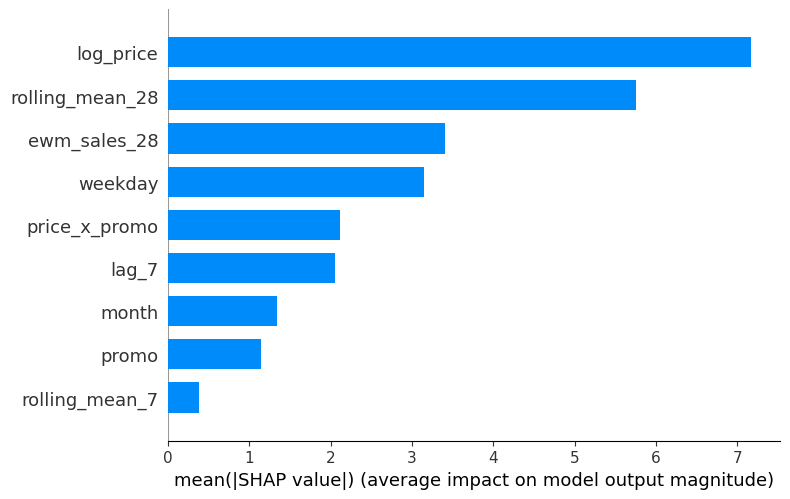

In [32]:
X_sample = train_df[feature_cols].sample(2000, random_state=42)
dmatrix = xgb.DMatrix(
    X_sample,
    enable_categorical=True
)
shap_values = model.get_booster().predict(
    dmatrix,
    pred_contribs=True
)
shap.summary_plot(shap_values[:, :-1], X_sample, plot_type="bar")

This extracts SHAP values from the model output, handling different possible array formats, and reduces them to a consistent 2D structure for analysis. It then computes the mean absolute SHAP value per feature and prints a ranked list showing which variables contribute most to the model’s predictions.

In [33]:
vals = shap_values.values if hasattr(shap_values, "values") else shap_values
if vals.ndim == 3:
    vals = vals[:, :, 0]
mean_shap = np.abs(vals).mean(axis=0)

for name, val in sorted(zip(X_sample.columns, mean_shap), key=lambda x: -x[1]):
    print(f"{name}: {val:.6f}")

log_price: 7.169364
rolling_mean_28: 5.754157
ewm_sales_28: 3.406384
weekday: 3.142637
price_x_promo: 2.117264
lag_7: 2.057313
month: 1.343130
promo: 1.141614
rolling_mean_7: 0.373700


In [34]:
import joblib
joblib.dump(model, "sales_model.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

['feature_cols.pkl']